<a href="https://colab.research.google.com/github/allenswdb/TReND-CaMinA/blob/main/notebooks/Kenya26/03_04-Wed1toThu2-AllenTutorial/project_templates/Project_7_Running_Variability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 <div align="center" style="background: #F0FAFF; border-radius: 3px; padding: 10px;">
    <h1> Project 7:  Variability in Running Responses </h1>
<h3 align="center">Tutorial TReND CaMiNa 2026 </h3> 

In the tutorial sessions, we looked at neural responses during the presentation of categorical stimuli.  We computed a "tuning curve" by averaging the responses to each of the presentations of these stimuli.  The fact that we could classify the stimuli into discrete values (45 degrees, 90 degrees, etc.) made this an easy an natural approach to quantifying the stimulus response of the neuron.  

During the experiment, the mouse is able to run and we have a measurement of the speed of the mouse during the recording session.  Unlike the drifting grating stimulus, this is a continuous variable.  How can we assess whether there is a "tuned" response to this variable?  This project explores a few ways to approach this problem.

Moreover, how do we validate our results?  We will see that this response is highly variable.  What does that mean for the stability and robustness of any "tuning" that we observe?  This is a question that will arise in a general data analysis context.  You might produce a description of data, or a "model", but will it be predictive of new data?  Is it consistent with new measurements?

In [ ]:
# @title Run to initialize Allen Brain Observatory on Colab {display-mode: "form" }

# run only once per runtime/session, and only if running in colab
# the runtime will need to restxart after
%%capture
!apt install s3fs

!pip uninstall -y numpy pandas
!pip install git+https://github.com/AllenInstitute/AllenSDK@1bdca3ad884c3a5edea8236161424650603e6f29 "numpy == 1.26.4" "pandas == 2.3.0" "matplotlib > 3.8.0" "statsmodels >= 0.14.4"
import allensdk
print('allensdk imported successfully')

!mkdir -p /data/allen-brain-observatory/
!s3fs allen-brain-observatory /data/allen-brain-observatory/ -o public_bucket=1

import time
print("Runtime is now restarting...")
print("You can ignore the error message [Your session crashed for an unknown reason.]")
time.sleep(5)
exit()

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import os

In [3]:
from allensdk.core.brain_observatory_cache import BrainObservatoryCache

In [4]:
import platform, os, sys
platstring = platform.platform()

if ('amzn' in platstring) or ('google.colab' in sys.modules):
    # for AWS
    vc_cache_dir = '/data/allen-brain-observatory/visual-coding-2p'
else:  
    # for local drive, different operating systems
    if ('Darwin' in platstring) or ('macOS' in platstring):
        # OS X 
        data_root = "/Volumes/TReND2026/"
    elif 'Windows'  in platstring:
        # Windows (replace with the drive letter of USB drive)
        data_root = "E:/"
    else:
        # your own linux platform
        # EDIT location where you mounted hard drive
        data_root = "/media/$USERNAME/TReND2026/"
        
    # visual behavior cache directory
    vc_cache_dir = os.path.join(data_root, "visual_coding_2p")
    
boc = BrainObservatoryCache(manifest_file=os.path.join(vc_cache_dir, 'manifest.json'))

We have selected an experiment container for you to look at below, along with a cell (identified by CELL_SPECIMEN_ID).  The following cells retrieve that data for the sessions in which that cell appears, along with the index of the cell for that particular session.  We will then look at the running behavior of the mouse during this session and compare that to the activity of a selected neuron.

In [2]:
CELL_SPECIMEN_ID = 517417614

In [5]:
def get_data_sets_for_cell(cell_specimen_id):
    
    exps = boc.get_ophys_experiments(cell_specimen_ids=[cell_specimen_id])
    
    data_set_dict = {}
    cell_index_dict = {}
    
    for sess in exps:
        sess_id = sess['id']
        session_type = sess['session_type']
        
        data = boc.get_ophys_experiment_data(sess_id)
        cell_index = data.get_cell_specimen_indices([cell_specimen_id])[0]
        
        data_set_dict[session_type[-1]] = data
        cell_index_dict[session_type[-1]] = cell_index
        
    return cell_index_dict, data_set_dict

In [6]:
cell_index_dict, data_set_dict = get_data_sets_for_cell(CELL_SPECIMEN_ID)

In [7]:
data_set_dict

{'A': <allensdk.core.brain_observatory_nwb_data_set.BrainObservatoryNwbDataSet at 0x7fc53808f9d0>,
 'C': <allensdk.core.brain_observatory_nwb_data_set.BrainObservatoryNwbDataSet at 0x7fc53808fc70>,
 'B': <allensdk.core.brain_observatory_nwb_data_set.BrainObservatoryNwbDataSet at 0x7fc53808fdf0>}

In [46]:
data = data_set_dict['A']
cell_id = cell_index_dict['A']
print("The cell_index for the cell {} in session 'A' is {}".format(CELL_SPECIMEN_ID, cell_id))

The cell_index for the cell 517417614 in session 'A' is 108


Let's get the data structures we need for this project.

The cell below gets the running speed (dx) and the time stamps of each acquisition frame (time).  Theses arrays are indexed by the acquisition frame of the microscope.  Plotting 'dx' vs. 'time' will give you the running speed as a function of the time in the experiment.  We'll plot this below.

In [9]:
dx, time = data.get_running_speed()

# Each array should have a length equal to the number of acquisition frames in this session.  These numbers should match.
dx.shape, time.shape

((115469,), (115469,))

Text(0.5, 0, 'time (s)')

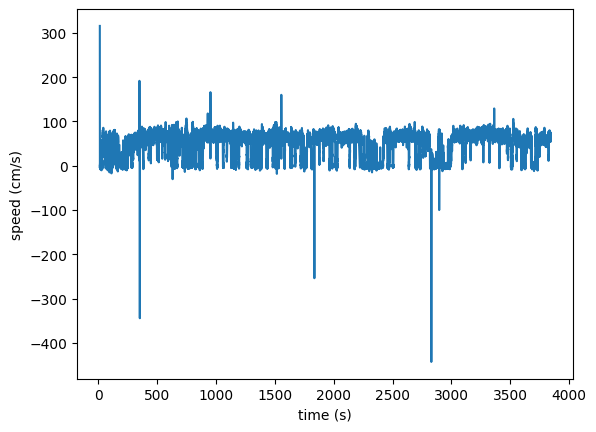

In [10]:
fig, ax = plt.subplots()
ax.plot(time, dx)
ax.set_ylabel('speed (cm/s)')
ax.set_xlabel('time (s)')

What is happening here?  Why does the data have this shape?  Why are there negative values?

Let's zoom in on this data.  What does the mouse do just after 500s?

In [11]:
np.where(time>500)

(array([ 14747,  14748,  14749, ..., 115466, 115467, 115468]),)

Text(0.5, 0, 'time (s)')

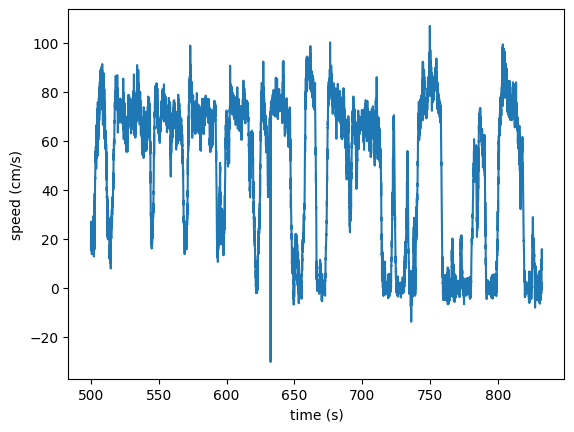

In [12]:
t0 = np.where(time>500)[0][0]
t1 = t0+10000

fig, ax = plt.subplots()
ax.plot(time[t0:t1], dx[t0:t1])
ax.set_ylabel('speed (cm/s)')
ax.set_xlabel('time (s)')

It appears that this mouse goes through brief bouts where it switches between running and standing still.  Occasionally, it also fidgets and pushes the running wheel away, which registers as moving backwards.

What about the distribution of running speeds?  What does that look like?

Text(0.5, 0, 'speed (cm/s)')

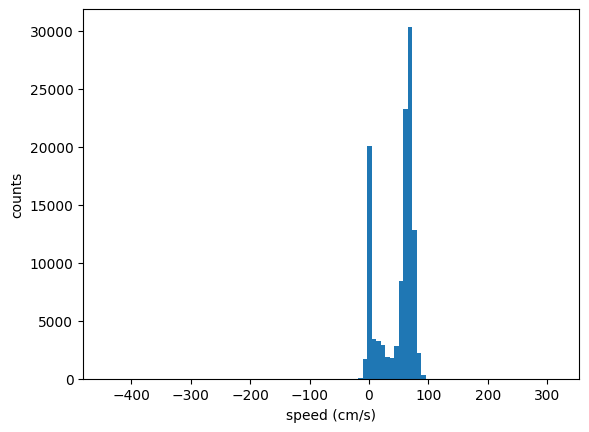

In [13]:
fig, ax = plt.subplots()
ax.hist(dx, bins=100)
ax.set_ylabel('counts')
ax.set_xlabel('speed (cm/s)')

You can see the distribution is dominated by clusters centered near 0 cm/s and maybe 60 cm/s.  Let's look at the distribution on a log scale in order to see the measure away from 0 cm/s.

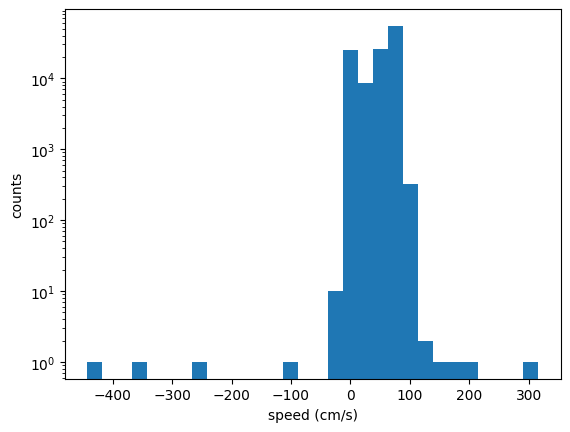

In [14]:
fig, ax = plt.subplots()
ax.hist(dx, bins=30)
ax.set_ylabel('counts')
ax.set_xlabel('speed (cm/s)')
ax.set_yscale('log')

The code below gets the flourescence traces of the set of neurons imaged in this session.  'time' should be the same array returned by the running function above.  'dff' is an array of shape [number_of_neurons, acquisition_frames].  It gives the fluorescence response (computed as "delta-F over F") for each neuron.

In [15]:
time, dff = data.get_dff_traces()

# 'time' is of shape [acquisition_frames], dff is of shape [number_of_neurons, acquisition_frames]
time.shape, dff.shape

((115469,), (153, 115469))

Let's look at the response vs. running speed for a neuron.  We'll compare our selected cell with another in the dataset (cell1).  Please choose some other indices to examine what this looks like.

In [16]:
cell1 = 1
cell2 = cell_index_dict['A']  # cell2 is the index we retrieved above

Text(0.5, 0, 'Running Speed (cm/s)')

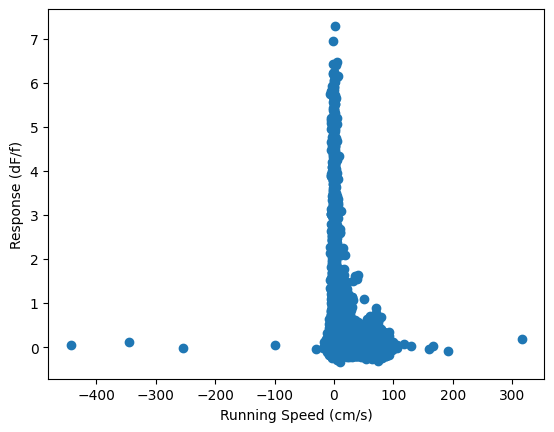

In [17]:
fig, ax = plt.subplots()
ax.plot(dx, dff[cell1],'o')
ax.set_ylabel('Response (dF/f)')
ax.set_xlabel('Running Speed (cm/s)')

Notice that the values in this scatter plot are largely clumped along the axes.  What hypotheses do you have for why this might be?

Now let's look at our other cell.

Text(0.5, 0, 'Running Speed (cm/s)')

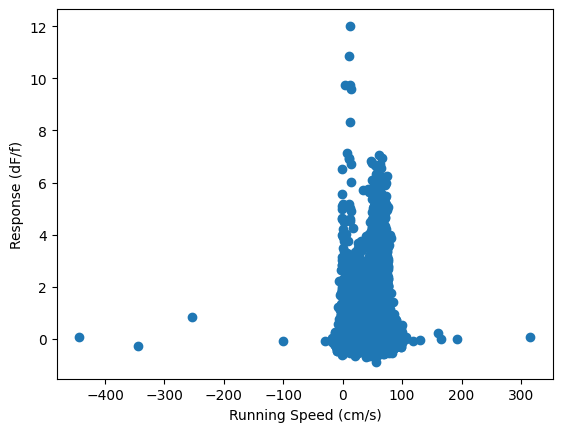

In [18]:
fig, ax = plt.subplots()
ax.plot(dx, dff[cell2],'o')
ax.set_ylabel('Response (dF/f)')
ax.set_xlabel('Running Speed (cm/s)')

In contrast, there is now a significant number of points that do not lie along the axes.  This suggests this neuron might be modulating its activity due to the mouse behavior.  Why can't we conclude that it is from just this plot?

Let's try to compute a 'running tuning curve'.  What is the average activity of the mouse given the mouse is running at a particular speed?

Since the running speed is a continuous variable, we will need to bin the values first.  The following function computes this curve using this approach.  BIN_SIZE is the size of the bins into which we will gather the running speed values.

In [19]:
def compute_running_tuning_curve(dx, response, bin_size=2, lower=-50, upper=150):
        
    bins = np.linspace(lower,upper,int((upper-lower)/bin_size))
    indices = np.digitize(dx, bins)
    
    num_bins = len(bins)
    tc = np.zeros(num_bins)
    tc_sem = np.zeros(num_bins)
    for n in range(num_bins):
        if len(response[indices==n])>0:
            tc[n] = np.mean(response[indices==n])
            tc_sem[n] = np.std(response[indices==n])/np.sqrt(len(response[indices==n]))
        else:
            tc[n] = 0.0
            tc_sem[n] = 0.0
        
    return bins, tc, tc_sem

Notice that the running distribution has several outliers.   For the moment, we will ignore these points by computing a tuning curve within a range that excludes them.  Looking at the above distribution, we set 'lower' and 'upper' to -50 cm/s and 150 cm/s, respectively.

In [20]:
speed_bins, running_tuning_curve, running_tc_sem = compute_running_tuning_curve(dx, dff[cell2], lower=-50, upper=150)

In [21]:
speed_bins

array([-50.        , -47.97979798, -45.95959596, -43.93939394,
       -41.91919192, -39.8989899 , -37.87878788, -35.85858586,
       -33.83838384, -31.81818182, -29.7979798 , -27.77777778,
       -25.75757576, -23.73737374, -21.71717172, -19.6969697 ,
       -17.67676768, -15.65656566, -13.63636364, -11.61616162,
        -9.5959596 ,  -7.57575758,  -5.55555556,  -3.53535354,
        -1.51515152,   0.50505051,   2.52525253,   4.54545455,
         6.56565657,   8.58585859,  10.60606061,  12.62626263,
        14.64646465,  16.66666667,  18.68686869,  20.70707071,
        22.72727273,  24.74747475,  26.76767677,  28.78787879,
        30.80808081,  32.82828283,  34.84848485,  36.86868687,
        38.88888889,  40.90909091,  42.92929293,  44.94949495,
        46.96969697,  48.98989899,  51.01010101,  53.03030303,
        55.05050505,  57.07070707,  59.09090909,  61.11111111,
        63.13131313,  65.15151515,  67.17171717,  69.19191919,
        71.21212121,  73.23232323,  75.25252525,  77.27

Text(0.5, 0, 'Mean running speed per bin (cm/s)')

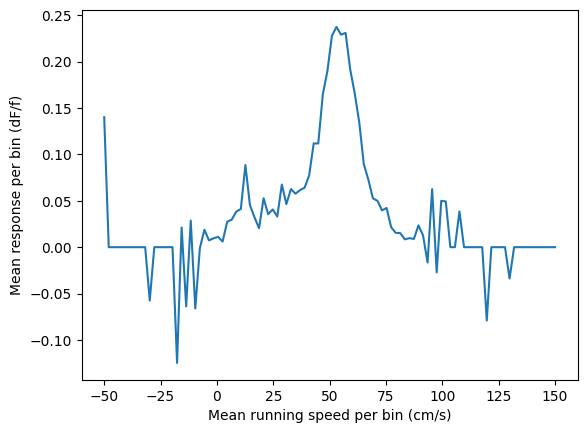

In [22]:
fig, ax = plt.subplots()
ax.plot(speed_bins, running_tuning_curve)
ax.set_ylabel('Mean response per bin (dF/f)')
ax.set_xlabel('Mean running speed per bin (cm/s)')

Does this look like this reasonably captures any effect we might be seeing in the response vs running speed plot above?  What's with the relatively large negative value?  

Let's look at different bin sizes for the running speed.

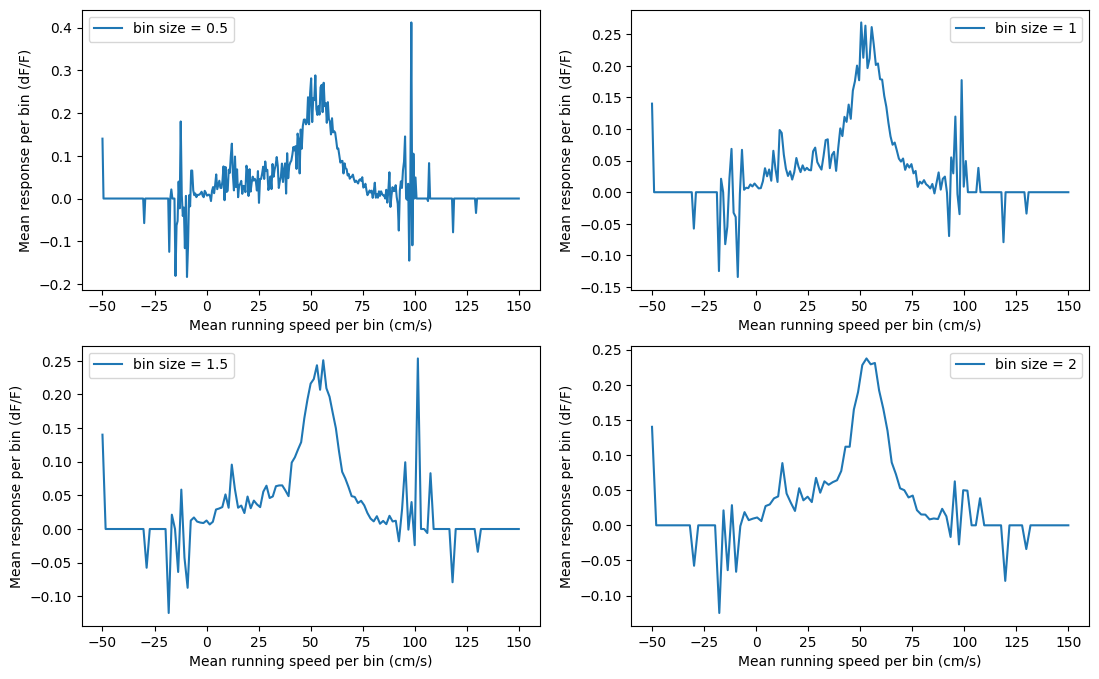

In [23]:
bin_sizes = [0.5, 1, 1.5 , 2]
lower=-50
upper=150

fig, ax = plt.subplots(2,2, figsize=(13,8))

for i, bin_size in enumerate(bin_sizes):
    
    speed_bins, running_tuning_curve, running_tc_sem = compute_running_tuning_curve(dx, dff[cell2], bin_size=bin_size, lower=lower, upper=upper)
    row = i//2
    col = i%2
    ax[row,col].plot(speed_bins, running_tuning_curve, label='bin size = '+str(bin_size))
    ax[row,col].legend()
    ax[row,col].set_ylabel('Mean response per bin (dF/F)')
    ax[row,col].set_xlabel('Mean running speed per bin (cm/s)')
    

We see several large deviations.  Some of these vanish as we increase the bin size.  Not all of them, though.  What's happening here?

One aspect of this approach (picking bin sizes for running speed of fixed width) is that we are not controlling the running speed of the animal in these experiments (how could we?) so we don't have a consistent set of points for each range of running speed values.  The function we used above returns the standard error of the mean for each bin so that we can look at the precision of our estimation for each bin.

Text(0.5, 0, 'Mean running speed per bin (cm/s)')

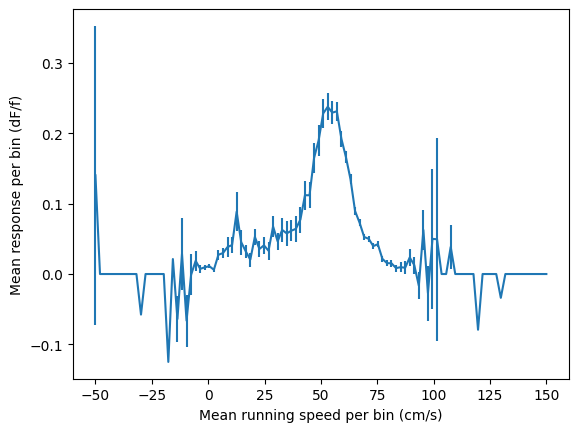

In [24]:
fig, ax = plt.subplots()
ax.errorbar(speed_bins, running_tuning_curve, running_tc_sem)
ax.set_ylabel('Mean response per bin (dF/f)')
ax.set_xlabel('Mean running speed per bin (cm/s)')

What's going on here?  Notice that some bins have a very small standard error (e.g. those between 0 cm/s and 85 cm/s).  That's because these have many, many points and so we can be very confident in our estimate of the average.  In other cases, we do not have many points and so the error in those bins is much larger.  This is clearly the case for the large values for negative running speed, which we should have expected since these are quite rare events.

One way that we can try to tackle this by considering a smoothed version of the running speed.  There are several ways to do this, let's try the simplest approach of using a moving window.

In [25]:
def moving_average(data, window_size):
    # Create a uniform window that sums to 1
    window = np.ones(window_size) / window_size
    # Use 'valid' to avoid edge artifacts, or 'same' to keep original size
    return np.convolve(data, window, mode='same')

Text(0.5, 0, 'time (s)')

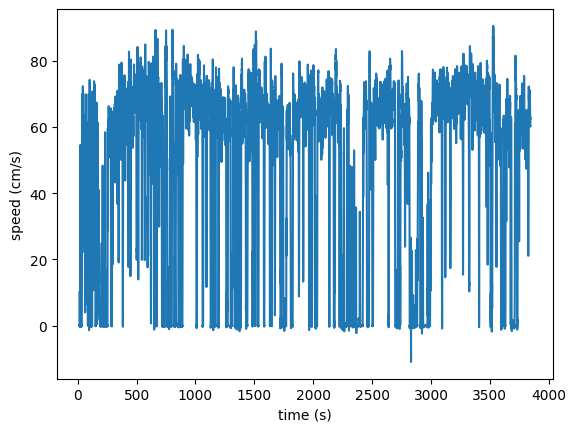

In [26]:
smooth_dx = moving_average(dx, 31)

fig, ax = plt.subplots()
ax.plot(time, smooth_dx)
ax.set_ylabel('speed (cm/s)')
ax.set_xlabel('time (s)')

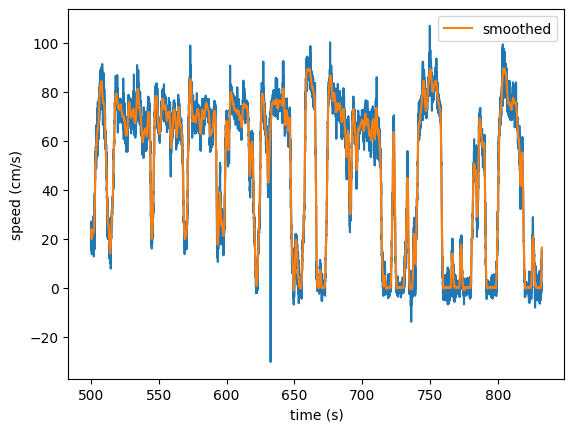

In [48]:
t0 = np.where(time>500)[0][0]
t1 = t0+10000

fig, ax = plt.subplots()
ax.plot(time[t0:t1], dx[t0:t1])
ax.plot(time[t0:t1], smooth_dx[t0:t1], label="smoothed")
ax.set_ylabel('speed (cm/s)')
ax.set_xlabel('time (s)')
ax.legend()

Notice that this removes some of the large deviations and, as expected, generally smooths the curve.  Compare the plot below to the one we made above.

Text(0.5, 0, 'Running Speed (cm/s)')

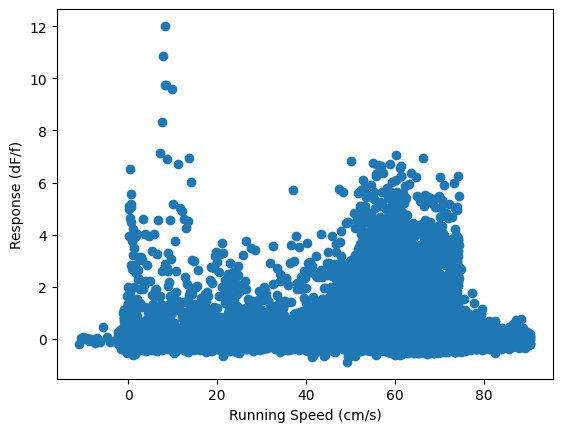

In [28]:
fig, ax = plt.subplots()
ax.plot(smooth_dx, dff[cell2],'o')
ax.set_ylabel('Response (dF/f)')
ax.set_xlabel('Running Speed (cm/s)')

The large outliers that we ignored by focusing on a particular range are now gone.  These are likely experimental errors.  In any case, they were not repeated events in the experiment and thus difficult to study.

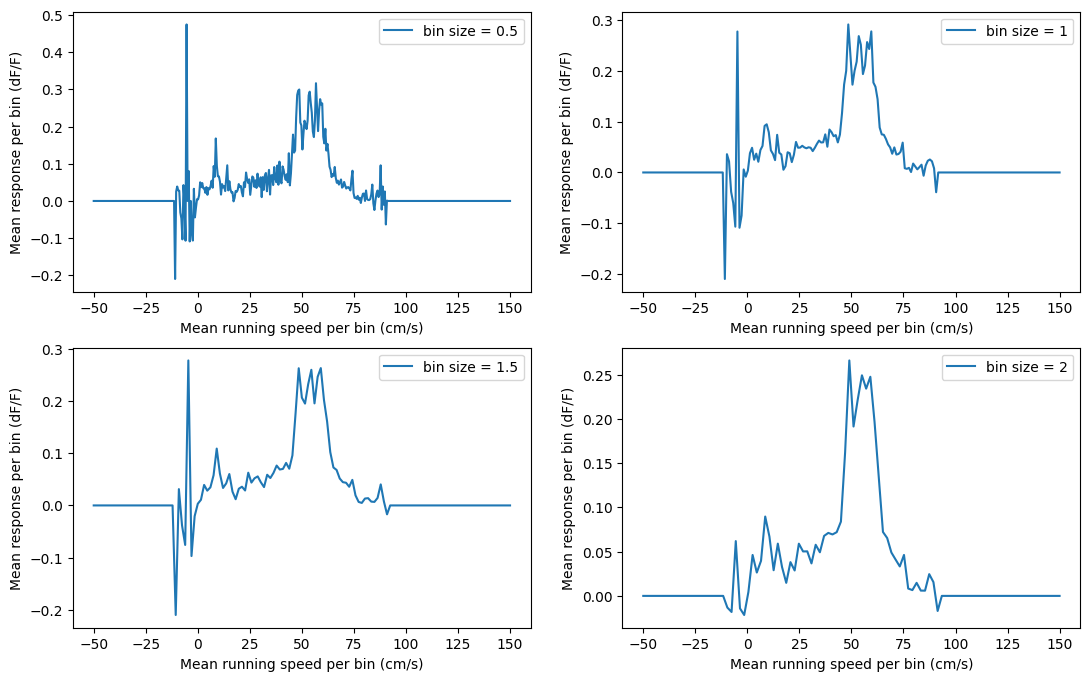

In [29]:
bin_sizes = [0.5, 1, 1.5, 2]
lower = -50
upper = 150 

fig, ax = plt.subplots(2,2, figsize=(13,8))

for i, bin_size in enumerate(bin_sizes):
    
    speed_bins, running_tuning_curve, running_tc_sem = compute_running_tuning_curve(smooth_dx, dff[cell2], bin_size=bin_size, lower=lower, upper=upper)
    row = i//2
    col = i%2
    ax[row,col].plot(speed_bins, running_tuning_curve, label='bin size = '+str(bin_size))
    ax[row,col].legend()
    ax[row,col].set_ylabel('Mean response per bin (dF/F)')
    ax[row,col].set_xlabel('Mean running speed per bin (cm/s)')

There is a consistent peak at around -5 cm/s.  Is this real?  What would a hypothesis for this response be?  One possibility:  maybe the mouse has a startle response that causes it to push the wheel backwards and that also corresponds to a pulse of activity.  Is this possibly the case?  On the other hand, we see this peak diminish as we incraese the bin size.

Let's take another look at the plot for bin_size=2 and add the standard error.

Text(0.5, 0, 'Mean running speed per bin (cm/s)')

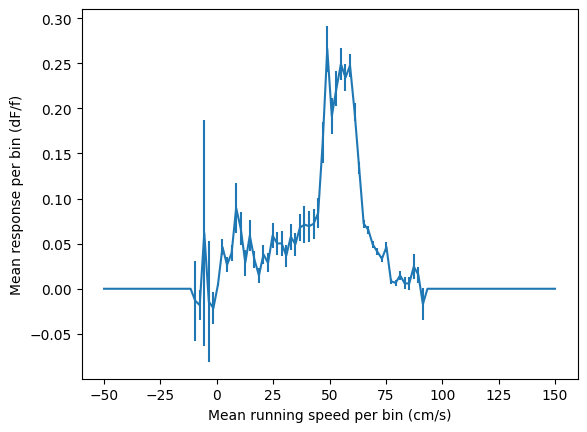

In [30]:
speed_bins, running_tuning_curve, running_tc_sem = compute_running_tuning_curve(smooth_dx, dff[cell2], bin_size=2)

fig, ax = plt.subplots()
ax.errorbar(speed_bins, running_tuning_curve, running_tc_sem)
ax.set_ylabel('Mean response per bin (dF/f)')
ax.set_xlabel('Mean running speed per bin (cm/s)')

Aha!  In this case, there are so few points in the bin, that the standard error is so large the interval nearly overlaps with 0!  So this peak is NOT a real effect most likely and our hypothesis is likely false.

Is there another way to address the issue that the running behavior is not a controlled variable in our experiment?  Another approach is to consider non-equal bin sizes.  We can group the observations of response and running speed into bins of an equal number of points.  This guarantees that the standard error will scale similarly for each bin.  On the other hand, we will potentially be averaging over observations with very different running speeds.

In [31]:
def compute_running_tc_variable_bin(dx, dff, num_bins=1000):
    N = len(dx)//num_bins
    
    dx_alt = dx[np.argsort(dx)][:N*num_bins].reshape(N, num_bins).mean(axis=1)
    dff_alt = dff[np.argsort(dx)][:N*num_bins].reshape(N, num_bins).mean(axis=1)
    dff_alt_sem = dff[np.argsort(dx)][:N*num_bins].reshape(N, num_bins).std(axis=1)/np.sqrt(N)
    
    return dx_alt, dff_alt, dff_alt_sem

Text(0.5, 0, 'Mean running speed per bin (cm/s)')

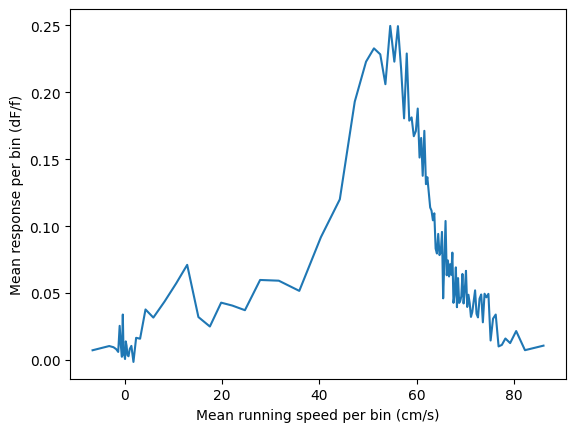

In [32]:
speed_bins, running_tuning_curve_vb, running_tc_vb_sem = compute_running_tc_variable_bin(dx, dff[cell2])

fig, ax = plt.subplots()
ax.plot(speed_bins, running_tuning_curve_vb)
ax.set_ylabel('Mean response per bin (dF/f)')
ax.set_xlabel('Mean running speed per bin (cm/s)')

This gives a pretty clean curve for the neural activity as a function of running speed.  Note that we don't have to go through the clunky exercise of removing outliers or setting an interval over which to compute the curve using this method. 

What do the standard errors look like?

Text(0.5, 0, 'Mean running speed per bin (cm/s)')

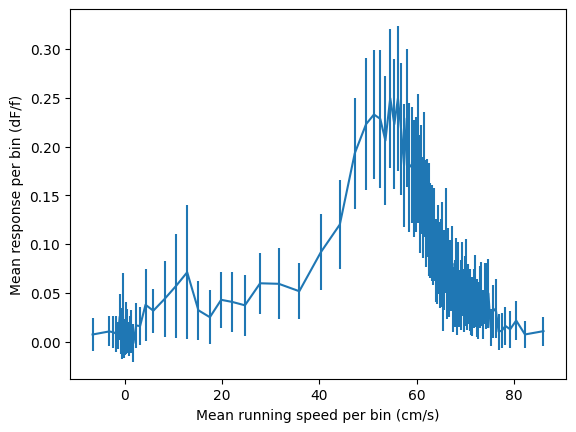

In [33]:
speed_bins, running_tuning_curve_vb, running_tc_vb_sem = compute_running_tc_variable_bin(dx, dff[cell2])

fig, ax = plt.subplots()
ax.errorbar(speed_bins, running_tuning_curve_vb, running_tc_vb_sem)
ax.set_ylabel('Mean response per bin (dF/f)')
ax.set_xlabel('Mean running speed per bin (cm/s)')

or with the smoothed running trace

Text(0.5, 0, 'Mean running speed per bin (cm/s)')

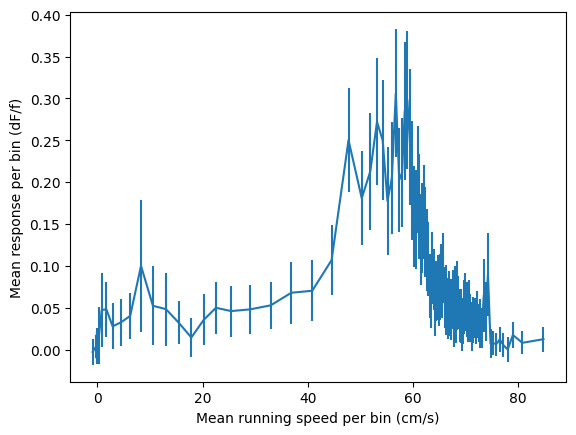

In [34]:
speed_bins, running_tuning_curve_vb, running_tc_vb_sem = compute_running_tc_variable_bin(smooth_dx, dff[cell2])

fig, ax = plt.subplots()
ax.errorbar(speed_bins, running_tuning_curve_vb, running_tc_vb_sem)
ax.set_ylabel('Mean response per bin (dF/f)')
ax.set_xlabel('Mean running speed per bin (cm/s)')

Most of the standard errors are now of similar size, with a few points standing out (e.g. the small peak at around 10 cm/s).

So this running tuning curves shows consistent neural activity for this cell when the animal is running between 45 cm/s and 65 cm/s. 

Does this reflect that the neuron in question is responding to the fact that the animal is running?  So far, what we have is only *descriptive* of the data.  We do not yet know whether this neuron shows this kind of behavior in a consistent way.  

How might we test this?  The first thing we can do is to separate the data and build multiple tuning curves with *different partitions* of the data.  How many ways can you think to do this?

Here are two:  

1.  We can randomly select points to be divided into a number of partitions, and then look at the variability of the tuning curves across these partitions.

2.  We can divide the experiment by *time*, e.g. the first half vs the second half, and ask how stable the tuning curve is.

Do these methods answer the same question?

Below is a function to divide the sequence of acquisition times into K partitions for each of these two methods.  Let's plot the tuning curves for each partition for each method.

In [35]:
np.random.permutation([1,2,3])[0:2]

array([1, 2])

In [36]:
def get_partitions(dx, dff, K, shuffle=True):
    """returns a dictionary of partitions, indexed by integer.
    
    dx:  running speed
    dff:  array of responses of shape [num_neurons, acquisition_frames]
    shuffle:  True means to randomize the points per partition, False means keep them in order.
    
    dx_part[i] = (dx, dff) # returns the (dx, dff) values for the ith partition"""
    
    index = np.arange(dx.shape[0])
    part_size = dx.shape[0]//K
    
    if shuffle:
        index = np.random.permutation(index)
    
    partition_dict = {}
    for k in range(K):
        part_index = index[k*part_size:(k+1)*part_size]
        partition_dict[k] = dx[part_index], dff[:, part_index]
        
    return partition_dict

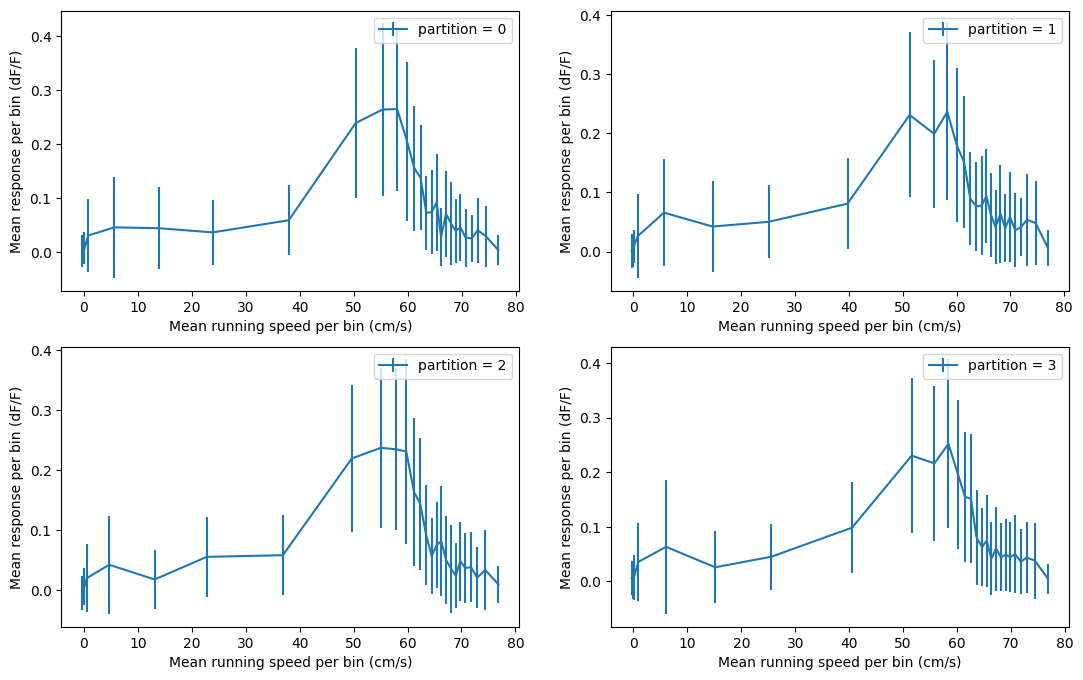

In [37]:
partition_dict = get_partitions(smooth_dx, dff, 4, shuffle=True)

fig, ax = plt.subplots(2,2, figsize=(13,8))

for i, part in enumerate(partition_dict):
    
    dx_part, dff_part = partition_dict[part]
    
    speed_bins, running_tuning_curve_vb, running_tc_vb_sem = compute_running_tc_variable_bin(dx_part, dff_part[cell2])
    
    row = i//2
    col = i%2
    ax[row,col].errorbar(speed_bins, running_tuning_curve_vb, running_tc_vb_sem, label='partition = '+str(i))
    ax[row,col].legend()
    ax[row,col].set_ylabel('Mean response per bin (dF/F)')
    ax[row,col].set_xlabel('Mean running speed per bin (cm/s)')

What can you conclude from these results?  How would you quantify the variation that you see here?

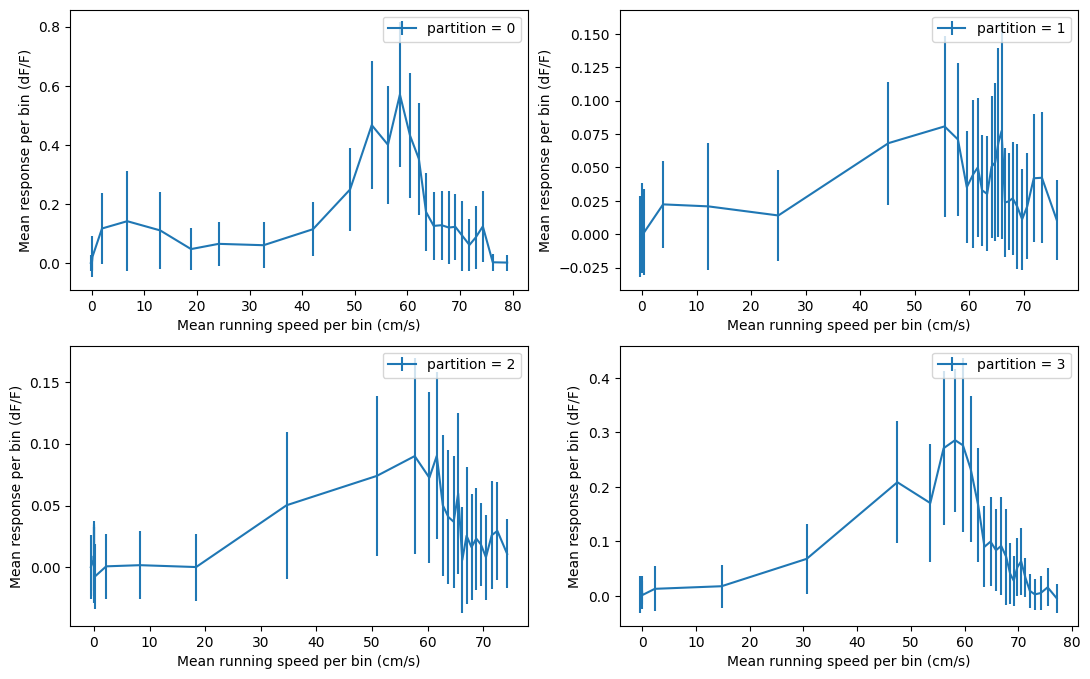

In [38]:
partition_dict = get_partitions(smooth_dx, dff, 4, shuffle=False)

fig, ax = plt.subplots(2,2, figsize=(13,8))

for i, part in enumerate(partition_dict):
    
    dx_part, dff_part = partition_dict[part]
    
    speed_bins, running_tuning_curve_vb, running_tc_vb_sem = compute_running_tc_variable_bin(dx_part, dff_part[cell2])
    
    row = i//2
    col = i%2
    ax[row,col].errorbar(speed_bins, running_tuning_curve_vb, running_tc_vb_sem, label='partition = '+str(i))
    ax[row,col].legend()
    ax[row,col].set_ylabel('Mean response per bin (dF/F)')
    ax[row,col].set_xlabel('Mean running speed per bin (cm/s)')

What can we conclude from these two kinds of partitioning?  How can you quantify this?  Start by computing the standard deviation of each tuning curve across these partitions.

Questions:

1.  Examine the variability in running tuning curves across different ways of partitioning the data.  How variable is the tuning response compared to its magnitude?  Can we conclude that this neuron is consistently responding when the animal is running?

2.  At the begining of the notebook, we pulled all three sessions in which this neuron appeared at saved those data in the dictionary 'data_set_dict'.  We have been using session 'A'.  Take a look at the other sessions this cell appears in.  The dictionary 'data_set_dict' is keyed by session letter ('A', 'B', or 'C') and each value is the data object for that session.  The cell_index_dict constructed above has valued that are the index of that cell in that particular session. 

Does the cell show the same tuning across sessions?  Why might there be differences?

In [39]:
data_set_dict

{'A': <allensdk.core.brain_observatory_nwb_data_set.BrainObservatoryNwbDataSet at 0x7fc53808f9d0>,
 'C': <allensdk.core.brain_observatory_nwb_data_set.BrainObservatoryNwbDataSet at 0x7fc53808fc70>,
 'B': <allensdk.core.brain_observatory_nwb_data_set.BrainObservatoryNwbDataSet at 0x7fc53808fdf0>}

In [40]:
cell_index_dict

{'A': 108, 'C': 79, 'B': 18}

3.  Pick another cell in some session.  You can do this by choosing one of the sessions ('A', 'B', or 'C') and choosing a random cell index.  Repeat this analysis.  Does this cell appear in every session?  What kind of tuning does it have?

In order to connect the cell across sessions you will need the index associated with that cell for each session.  The following function takes a session letter and a cell index and returns another cell_index_dict for your new cell.

In [41]:
def get_cell_index_dict(cell_id, session_type, data_set_dict):
    
    cell_specimen_id = data_set_dict[session_type].get_cell_specimen_ids()[cell_id]
    
    cell_index_dict = {}
    
    for key in data_set_dict:
        
        try:
            cell_index = data_set_dict[key].get_cell_specimen_indices([cell_specimen_id])[0]
        except ValueError:
            pass
        
        cell_index_dict[key] = cell_index
        
    return cell_index_dict

In [42]:
get_cell_index_dict(1, 'A', data_set_dict)

{'A': 1, 'C': 14, 'B': 77}

The directions below all move in different directions.  Pick the ones that interest you.

4.  Try classifying the cell tuning for each cell in this set of experiments.  For example, low-speed, mid-speed, or high-speed tuned cells.  What is the distribution of tuning types across these three sessions?  Which cells have consistent tuning?



5.  Can you think of a type of model you can fit to these tuning curves?  One option is to use linear regression to fit a polynomial.  What order polynomial should you use?  How do you decide?  How do you test or validate this model?

6.  What happens if you pool the activity of all neurons in the session into one average activity trace?  How does that population averaged activity relate to running?

7.  As you have seen, using the exact running speed has some downsides.  Perhaps it is easier to assign a discrete variable to the running state of the animal (e.g. "running" vs "stationary" or "stationary", "low speed" and "high speed").  How would you define these states?  How would you decide whether these running states had any effect on the response of a neuron?  One possibility is to use a Gaussian Mixture Model to define the running states by clustering the running speed distribution.  Then you can use linear regression to assess the degree to which each running state is predictive of the response.  Can you think of other approaches?

8.  How correlated is the running response to the running speed?  What is the distribution of these correlations across all the neurons in the session?

8.  Is there a simple relationship with the stimuli?  The stimulus epoch table shows which acquisition frames bound the presentation of stimulus types.  Are the tuning curves different during different stimulus epochs?  (Note:  a deeper look at this question is the focus of another project.)

The stimulus epoch table tells you which acquisition frames bound the presentation of any given stimulus type.  

In [43]:
data.get_stimulus_epoch_table()

,stimulus,start,end
0,drifting_gratings,743,18773
1,natural_movie_three,19706,37766
2,natural_movie_one,38670,47700
3,drifting_gratings,48604,66633
4,spontaneous,66783,75692
5,natural_movie_three,75693,93752
6,drifting_gratings,94656,115213


9.  Once you've gotten a handle on this experiment session, consider looking at other sessions.  Use the website https://observatory.brain-map.org/visualcoding/search/cell_list?sort_field=p_sg&sort_dir=asc to find cells that might be interesting and analyze that data.  You can retrieve that data by using the functions defined in this notebook.

We list helpful functions defined in this notebook below:
```
cell_index_dict, data_set_dict = get_data_sets_for_cell(CELL_SPECIMEN_ID)
# returns two dictionaries containing the data sets for each session that the cell CELL_SPECIMEN_ID appears in
# along with the cell_index of that cell for the corresponding session.  Use this if you need to retrieve data
# for a NEW set of experiments.  Most of the exercises above do NOT require rerunning this function.
# DEFINED IN THIS NOTEBOOK

dx, time = data.get_running_speed()
# retrieve the running speed ('dx') and time stamps ('time') of the behavior measurements

time, dff = data.get_dff_traces()
# retrieve the time stamps ('time') and delta-F over F values ('dff', of shape [num_neurons, num_acquisition_frames])
# recorded in that experiment session.

smooth_dx = moving_average(dx, win_size)
# a simple function to smooth the array 'dx' using a window size given in by win_size
# DEFINED IN THIS NOTEBOOK

speed_bins, running_tuning_curve_vb, running_tc_vb_sem = compute_running_tc_variable_bin(dx, dff_trace)
# returns the speed values (in cm/s), the running tuning curve, and the standard error for 
# the cell whose dff is given by dff_trace
# DEFINED IN THIS NOTEBOOK

partition_dict = get_partitions(dx, dff, K, shuffle)
# returns a dictionary of K partitions, keyed by integer with
# dx and dff separated according to those partitions.
# note: dff should be the array of ALL cells, not a single trace.
# shuffle=True will shuffle the data points, otherwise
# they will be partitioned in time.
# DEFINED IN THIS NOTEBOOK

get_cell_index_dict(cell_index, session_type, data_set_dict)
# given a cell_index (of the dff array) within a specific session of session_type ('A', 'B', or 'C')
# and using the data given in data_set_dict
# this returns a dictionary with the cell index values for that same cell 
# in each session.  The value for the session indicated by 'session_type'
# should match 'cell_index'
# DEFINED IN THIS NOTEBOOK
```